# Análisis Exploratorio Inicial: Visión General del Dataset

Exploración macro del padrón FIDE procesado (~776K jugadores) para identificar patrones globales
en distribución de ratings, concentración geográfica y estructura de títulos.

**Dataset:** `fide_players_all.parquet`

## Índice

1. [Carga y Exploración Inicial](#1-carga-y-exploración-inicial)
2. [Distribución de Elo Global](#2-distribución-de-elo-global) — KDE comparativo Clásico vs Rápido vs Blitz
3. [Concentración Geográfica](#3-concentración-geográfica) — Top 15 federaciones por volumen
4. [Estructura de Títulos Mundiales](#4-estructura-de-títulos-mundiales) — Distribución de títulos internacionales
5. [Títulos por Federación](#5-títulos-por-federación) — Crosstab y heatmap de cuota mundial


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from  scipy.stats import norm, t
from math import sqrt
import seaborn as sns


## 1. Carga y Exploración Inicial

Carga del dataset procesado con todos los jugadores que poseen al menos un rating > 0.

In [11]:
df = pd.read_parquet('../data/processed/fide_players_all.parquet')
df.head(10)

,fideid,name,country,sex,title,w_title,o_title,rating,rapid_rating,blitz_rating,birthday,flag,es_activo,edad,categoria
0,537001345,A Arbhin Vanniarajan,IND,M,nt,nt,nt,1450,1500,1431,2018,a,True,8,Sub 10
1,10245154,"A B M Jobair, Hossain",BAN,M,nt,nt,nt,1715,1738,1748,1998,a,True,28,Absoluta
2,558074015,A Bala Phani Prabhanjan,IND,M,nt,nt,nt,1585,1553,1524,2012,a,True,14,Sub 16
3,12457558,A Bu Ba Co,VIE,M,nt,nt,nt,<NA>,1638,<NA>,2002,a,True,24,Absoluta
4,25121731,A C J John,IND,M,nt,nt,nt,1438,<NA>,<NA>,1987,i,False,39,Absoluta
5,577037626,A C Jayaraghavan,IND,M,nt,nt,nt,1406,1407,<NA>,2012,a,True,14,Sub 16
6,35077023,A Chakravarthy,IND,M,nt,nt,nt,1491,<NA>,<NA>,1986,i,False,40,Absoluta
7,537070436,A Darshil,IND,M,nt,nt,nt,1489,1609,1542,2013,a,True,13,Sub 14
8,10207538,"A E M, Doshtagir",BAN,M,nt,nt,nt,1904,1902,1916,1974,i,False,52,Absoluta
9,532004656,"A F M Ehteshamul, Hoque (tuhin",BAN,M,nt,nt,nt,1859,1760,<NA>,1977,a,True,49,Absoluta


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 776188 entries, 0 to 776187
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   fideid        776188 non-null  string  
 1   name          776188 non-null  string  
 2   country       776188 non-null  category
 3   sex           776188 non-null  category
 4   title         776188 non-null  category
 5   w_title       776188 non-null  category
 6   o_title       776188 non-null  category
 7   rating        558367 non-null  Int64   
 8   rapid_rating  469675 non-null  Int64   
 9   blitz_rating  311496 non-null  Int64   
 10  birthday      776188 non-null  Int64   
 11  flag          776188 non-null  category
 12  es_activo     776188 non-null  bool    
 13  edad          776188 non-null  Int64   
 14  categoria     776188 non-null  str     
dtypes: Int64(5), bool(1), category(6), str(1), string(2)
memory usage: 81.8 MB


Comparación de las curvas de densidad (KDE) entre los tres ritmos oficiales:
- **Clásico** (rating)
- **Rápido** (rapid_rating)
- **Blitz** (blitz_rating)

> Permite visualizar si las distribuciones tienen formas similares o si hay diferencias de localización y dispersión.

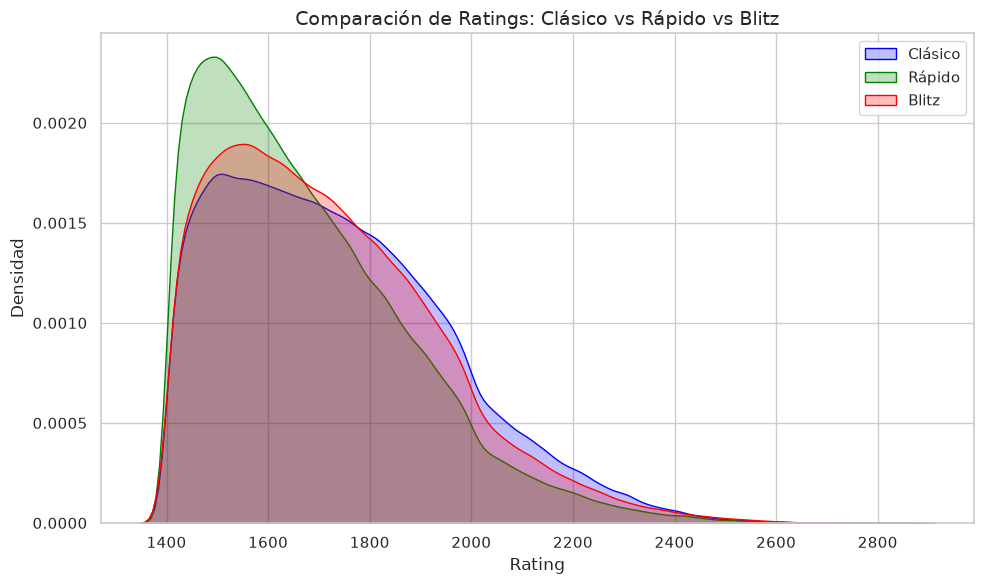

In [13]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))


sns.kdeplot(df[df['rating'] > 0]['rating'], fill=True, color='blue', label='Clásico')
sns.kdeplot(df[df['rapid_rating'] > 0]['rapid_rating'], fill=True, color='green', label='Rápido')
sns.kdeplot(df[df['blitz_rating'] > 0]['blitz_rating'], fill=True, color='red', label='Blitz')

plt.title('Comparación de Ratings: Clásico vs Rápido vs Blitz', fontsize=14)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Densidad', fontsize=12)

plt.legend()


plt.tight_layout()
plt.show()

### 3.1. Top 15 Federaciones — Tabla de Frecuencias

In [14]:
federaciones = df['country'].value_counts().rename_axis('federacion').reset_index(name='conteo')
federaciones['proporcion'] = federaciones['conteo'] / federaciones['conteo'].sum()
federaciones['porcentaje'] = np.round(federaciones['proporcion'],3) * 100

federaciones.head(10)

,federacion,conteo,proporcion,porcentaje
0,IND,71907,0.092641,9.3
1,RUS,70902,0.091346,9.1
2,FRA,52416,0.067530,6.8
3,ESP,43882,0.056535,5.7
4,GER,40223,0.051821,5.2
5,IRI,31032,0.039980,4.0
6,POL,29402,0.037880,3.8
7,ITA,21356,0.027514,2.8
8,BRA,17358,0.022363,2.2
9,UKR,13950,0.017972,1.8


### 3.2. Top 15 Federaciones — Visualización

Gráfico de barras horizontales mostrando la concentración absoluta de jugadores por federación.

> **Nota:** Este ranking es por volumen absoluto. Países pequeños con alta cultura ajedrecística
> (Armenia, Islandia, Georgia) no aparecen aquí. Ver futuro análisis per cápita.

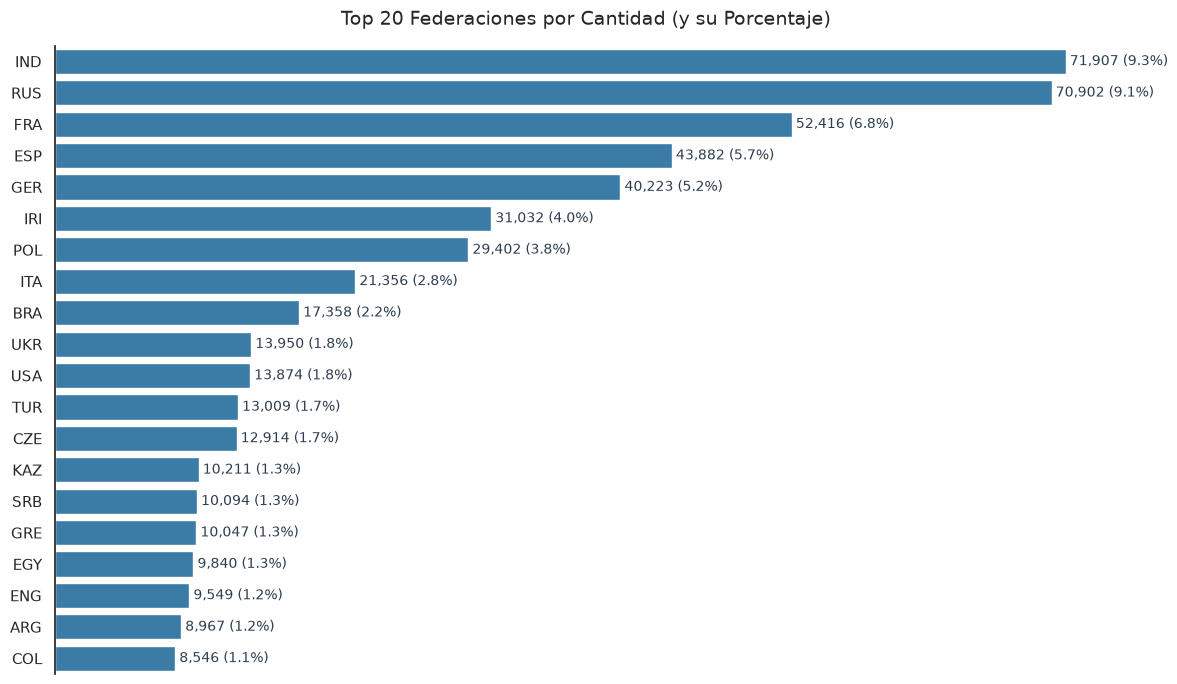

In [15]:

federaciones = df['country'].value_counts().rename_axis('federacion').reset_index(name='conteo')
federaciones['proporcion'] = federaciones['conteo'] / federaciones['conteo'].sum()
federaciones['porcentaje'] = np.round(federaciones['proporcion'], 4) 

top_15 = federaciones.head(20)


sns.set_theme(style="white") 


fig, ax = plt.subplots(figsize=(12, 7))


sns.barplot(
    data=top_15, 
    x='conteo', 
    y='federacion', 
    color='#2980b9',
    order=top_15['federacion'],
    ax=ax
)


ax.set_title('Top 20 Federaciones por Cantidad (y su Porcentaje)', fontsize=14, pad=15)
ax.set_ylabel('') 
ax.set_xlabel('') 
ax.xaxis.set_visible(False) 


sns.despine(bottom=True) 


for i, barra in enumerate(ax.patches):
    ancho = barra.get_width()
    pct = top_15['porcentaje'].iloc[i] 
    
    texto = f' {int(ancho):,} ({pct*100:.1f}%)' 
    
    ax.text(
        ancho,                           
        barra.get_y() + barra.get_height() / 2, 
        texto,
        ha='left', va='center', fontsize=10, color='#2c3e50'
    )

fig.tight_layout()
plt.show()


Distribución de frecuencias y porcentajes de cada título internacional sobre el total de la base.

> El ~96.8% carece de título (`nt`), y el ~3.2% restante se distribuye entre FM, IM, CM, GM y títulos femeninos.

In [16]:
titulos = df['title'].value_counts().rename_axis('titulos').reset_index(name='conteo')
titulos['proporcion'] = titulos['conteo'] / titulos['conteo'].sum()
titulos['porcentaje'] = titulos['proporcion']


titulos

,titulos,conteo,proporcion,porcentaje
0,nt,751650,0.968387,0.968387
1,FM,9695,0.012491,0.012491
2,IM,4290,0.005527,0.005527
3,CM,3817,0.004918,0.004918
4,WFM,2213,0.002851,0.002851
5,GM,1899,0.002447,0.002447
6,WCM,1353,0.001743,0.001743
7,WIM,927,0.001194,0.001194
8,WGM,344,0.000443,0.000443


### 5.1. Crosstab País × Título + Heatmap de Cuota Mundial

Tabla cruzada que calcula el porcentaje que representa cada federación dentro del total mundial de cada título.

In [17]:



titulos_FED = (
    pd.crosstab(index=df['country'], columns=df['title'])
    .assign(Total=lambda x: x.sum(axis=1))   
    .sort_values(by='Total', ascending=False) 
    .reset_index()                            
)

titulos_FED.columns.name = None \

nuevo_orden = [
    'country', 
    'GM', 'IM', 'FM', 'CM',      
    'WGM', 'WIM', 'WFM', 'WCM',  
    'nt',                       
    'Total'                      
]

titulos_FED = titulos_FED[nuevo_orden]

titulos_FED .head(10)

,country,GM,IM,FM,CM,WGM,WIM,WFM,WCM,nt,Total
0,IND,96,171,194,169,15,46,79,73,71064,71907
1,RUS,184,482,1239,100,39,96,401,38,68323,70902
2,FRA,60,133,299,96,9,19,36,6,51758,52416
3,ESP,60,151,470,219,3,15,57,10,42897,43882
4,GER,103,301,993,209,22,38,93,17,38447,40223
5,IRI,16,28,89,29,2,9,19,14,30826,31032
6,POL,56,122,242,131,13,30,66,39,28703,29402
7,ITA,18,52,194,38,1,4,18,4,21027,21356
8,BRA,15,34,122,64,0,8,14,17,17084,17358
9,UKR,85,188,206,28,19,30,37,4,13353,13950


### 5.2. Detalle con Títulos Completos

Incluye la categoría `nt` (no titulados) para contexto completo.

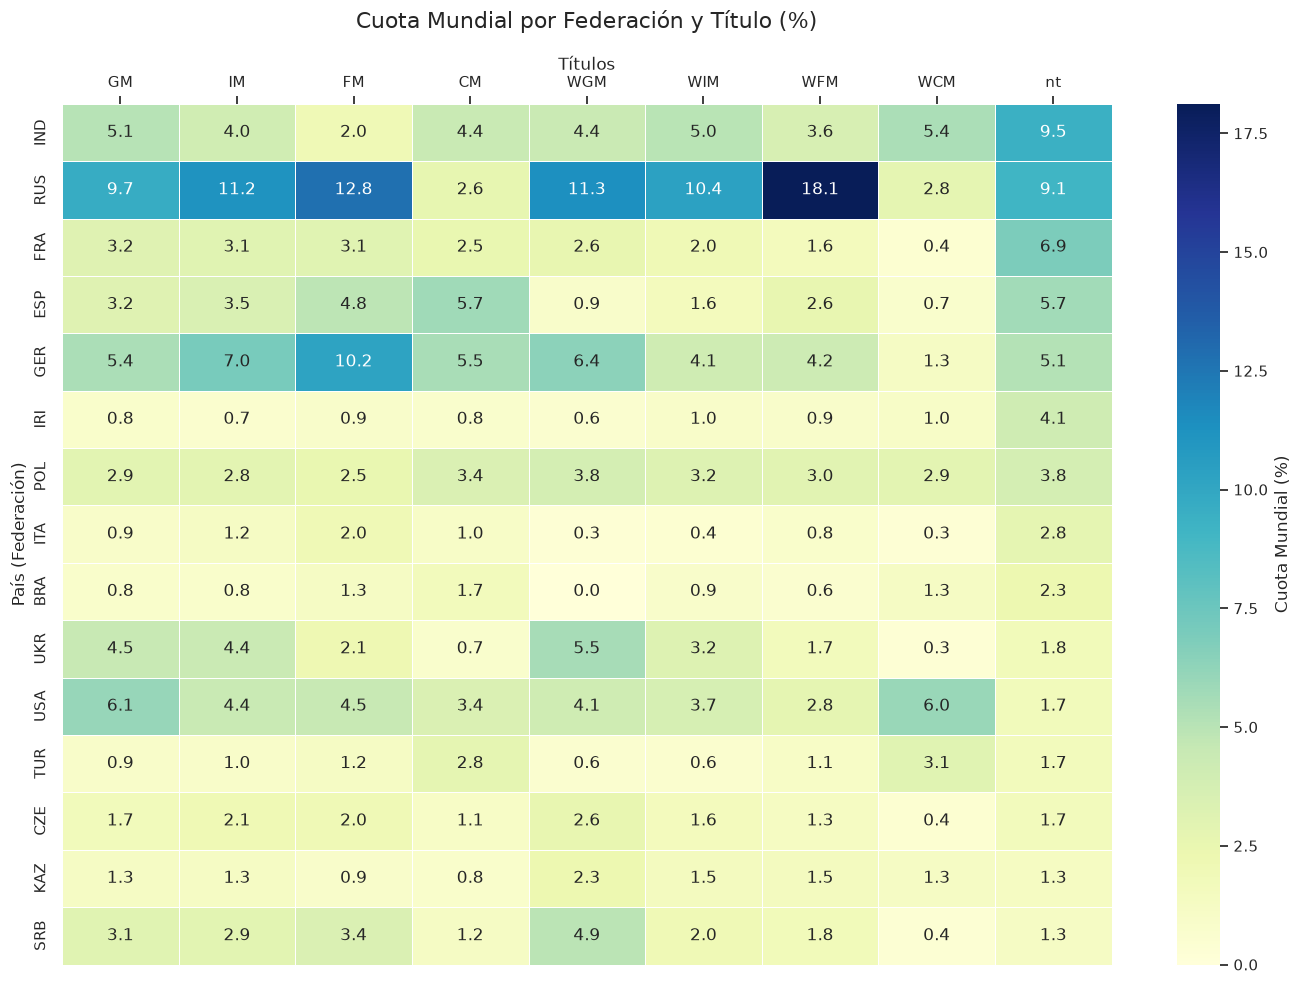

In [18]:

titulos_con_nt = ['GM', 'IM', 'FM', 'CM', 'WGM', 'WIM', 'WFM', 'WCM', 'nt']
df_plot_completo = titulos_FED.head(15)[['country'] + titulos_con_nt].set_index('country')
totales_mundiales = titulos_FED[titulos_con_nt].sum()
df_plot_cuota_mundial = (df_plot_completo.div(totales_mundiales, axis=1)) * 100

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(df_plot_cuota_mundial, cmap="YlGnBu", annot=True, fmt=".1f", 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Cuota Mundial (%)'})

ax.set_title("Cuota Mundial por Federación y Título (%)", fontsize=16, pad=20)
ax.set_xlabel("Títulos", fontsize=12)
ax.set_ylabel("País (Federación)", fontsize=12)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top') 
plt.tight_layout()
plt.show()

